# 01  Data Exploration & Cleaning

Uses the same components as the trading bot (config, logger, data manger) to pull live Alpaca market data, inspect it quickly, clean it, and persist a canonical dataset for downstream notebooks

In [42]:
import os
import sys
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd()
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config.settings import load_config
from src.utils.logger import get_logger
from src.data.data_manager import DataManager

config = load_config()
logger = get_logger('notebooks.data_exploration')
data_manager = DataManager(config=config)

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)
plt.style.use('seaborn-v0_8')
sns.set_palette('crest')

Loading cofiguration from /home/ciprimarian/Repos/ Local Repos/tradingbot/src/config/trading_config.yaml...
2025-11-18 16:39:24,360 | INFO | src.data.market_data | Market Data handler initialized | base_url: https://data.alpaca.markets


## Fetch live mrket data

Pull Alpaca bars through `DataManager` using the same symbol/timeframe defined in 'trading_config.yaml' 

In [43]:
symbol = config['trading']['symbol']
timeframe = config['data']['timeframe']
start_date = config['data'].get('start_date', '2023-01-01')
end_date = config['data'].get('end_date', '2025-01-01')

logger.info("Loading data | %s %s %s→%s", symbol, timeframe, start_date, end_date)
df_raw = data_manager.get_historical_data(
    symbol=symbol,
    timeframe=timeframe,
    start_date=start_date,
    end_date=end_date
)
df_raw = df_raw.sort_index()
display(df_raw.head())

2025-11-18 16:39:26,761 | INFO | notebooks.data_exploration | Loading data | NVDA 1Day 2024-01-01→2025-01-01
2025-11-18 16:39:26,762 | INFO | src.data.data_manager | Fetching data | symbol=NVDA, timeframe=1Day, start=2024-01-01, end=2025-01-01, limit=100
2025-11-18 16:39:26,763 | INFO | src.data.market_data | Fetching bars | symbol=NVDA, timeframe=1Day, start=2024-01-01, end=2025-01-01, limit=100
Succesfully fetched and processed data


,open,high,low,close,volume
t,,,,,
2024-01-02 05:00:00+00:00,492.44,492.950,475.9500,481.68,41133111
2024-01-03 05:00:00+00:00,474.85,481.841,473.2000,475.69,32097119
2024-01-04 05:00:00+00:00,477.67,485.000,475.0800,479.98,30662544
2024-01-05 05:00:00+00:00,484.62,495.470,483.0601,490.97,41503927
2024-01-08 05:00:00+00:00,495.12,522.750,494.7900,522.53,64308094


## Quick checks

Look for obvious data issues before cleaning

In [44]:
print(f"Rows: {len(df_raw):,}")
print(f"Date Range: {df_raw.index.min()} to {df_raw.index.max()}")

summary = df_raw.describe().T
missing = df_raw.isnull().sum()
summary['missing'] = missing
summary

Rows: 100
Date Range: 2024-01-02 05:00:00+00:00 to 2024-05-23 04:00:00+00:00


,count,mean,std,min,25%,50%,75%,max,missing
open,100.0,7.8589e+02,1.4155e+02,4.7485e+02,6.8296e+02,8.4289e+02,8.9624e+02,1.0203e+03,0
high,100.0,8.0042e+02,1.4431e+02,4.8184e+02,6.9690e+02,8.6213e+02,9.1016e+02,1.0632e+03,0
low,100.0,7.7078e+02,1.3741e+02,4.7320e+02,6.6979e+02,8.3111e+02,8.7771e+02,1.0152e+03,0
close,100.0,7.8683e+02,1.4008e+02,4.7569e+02,6.9055e+02,8.4954e+02,8.9559e+02,1.0380e+03,0
volume,100.0,4.9918e+07,1.4804e+07,2.8322e+07,3.9703e+07,4.7553e+07,5.8623e+07,1.1423e+08,0


## Plot a couple of views

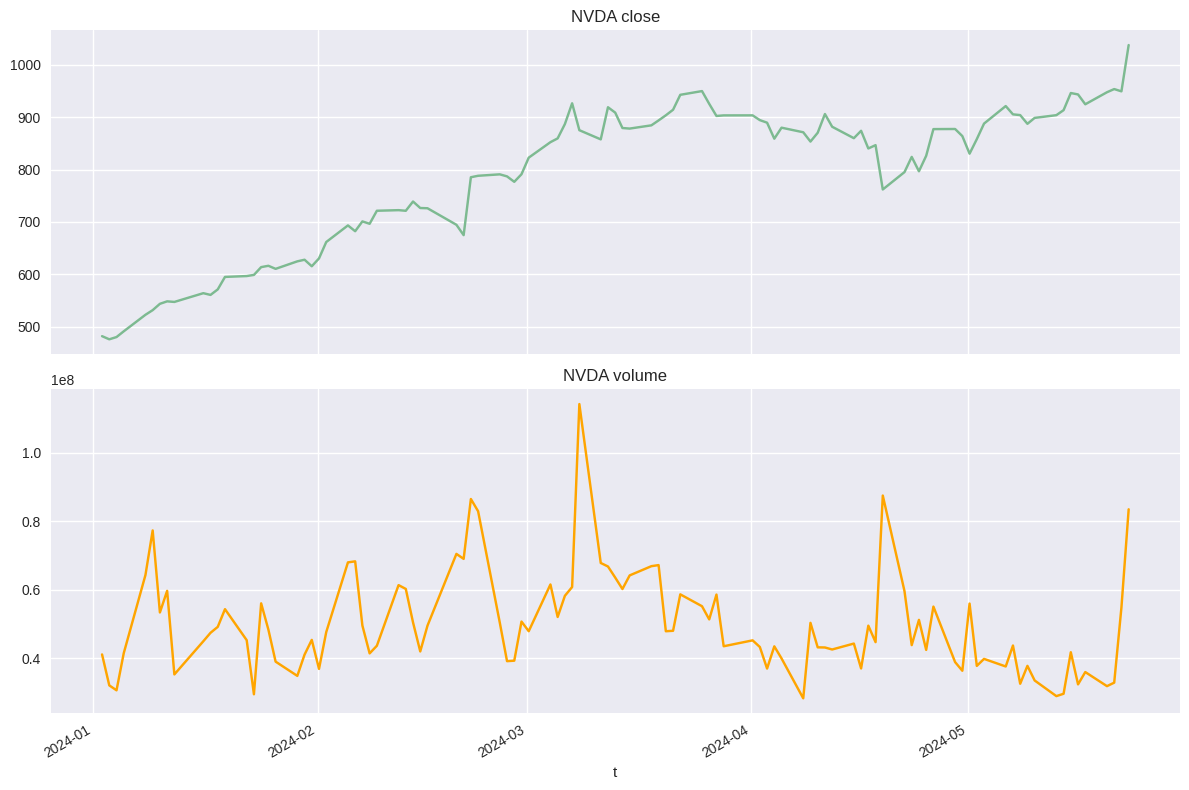

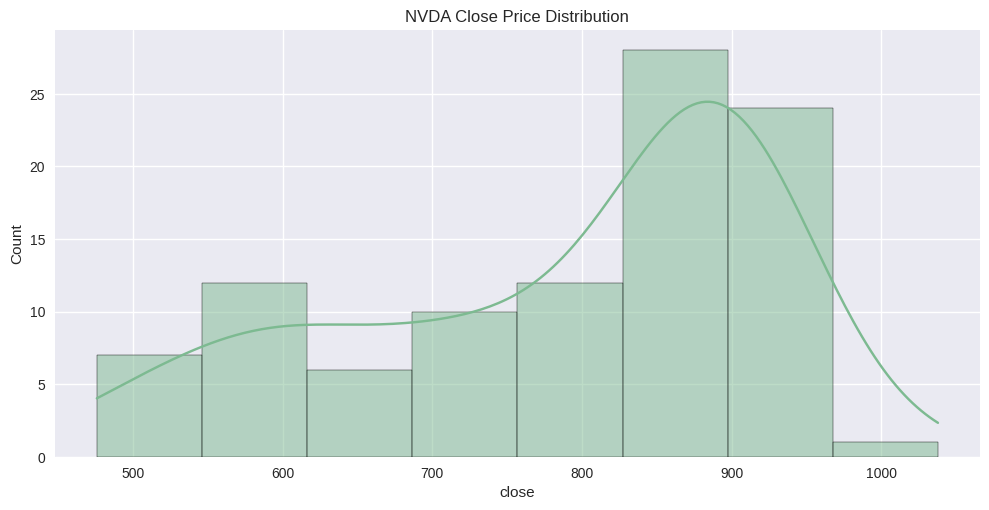

In [45]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
df_raw['close'].plot(ax=axes[0], title=f'{symbol} close')
df_raw['volume'].plot(ax=axes[1], title=f'{symbol} volume', color='orange')
plt.tight_layout()
plt.show()

sns.displot(df_raw['close'], kde=True, height=5, aspect=2)
plt.title(f'{symbol} Close Price Distribution')
plt.show()

## Clean + Persist

Use `DataManager.clean_data` for consistency and store the result for the next notebook

In [46]:
df_clean = data_manager.clean_data(df_raw)
logger.info("Cleaned dataset shape: %s", df_clean.shape)

df_clean = df_clean.ffill()
if df_clean['close'].isna().any():
    df_clean['close'].bfill(inplace=True)

path = data_manager.save_data(df_clean, "cleaned_data")
print(f"Cleaned data saved to: {path}")
df_clean.head()

2025-11-18 16:39:35,392 | INFO | notebooks.data_exploration | Cleaned dataset shape: (100, 5)
2025-11-18 16:39:35,397 | INFO | src.data.data_manager | Saving dataset cleaned_data to data/processed/cleaned_data.parquet
Cleaned data saved to: data/processed/cleaned_data.parquet


,open,high,low,close,volume
t,,,,,
2024-01-02 05:00:00+00:00,492.44,492.950,475.9500,481.68,41133111
2024-01-03 05:00:00+00:00,474.85,481.841,473.2000,475.69,32097119
2024-01-04 05:00:00+00:00,477.67,485.000,475.0800,479.98,30662544
2024-01-05 05:00:00+00:00,484.62,495.470,483.0601,490.97,41503927
2024-01-08 05:00:00+00:00,495.12,522.750,494.7900,522.53,64308094
